<h1>Expolatory Data Analysis</h1>

<h2>1. Setup & Load Data</h2>

<h4>1.1 Setup</h4>

In [1]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

<h4>1.2 Load Data</h4>

In [2]:
PROCESSED_DIR = "../data/processed"
MERGED_PATH = os.path.join(PROCESSED_DIR, "air_quality_merged_clean.csv")

df = pd.read_csv(MERGED_PATH, parse_dates = ["date"])
print("Loaded : ", df.shape)
df.head()

Loaded :  (8125, 23)


,id,data_period,date,station,PM10,PM25,SO2,CO,O3,NO2,...,s5p_co,s5p_no2,s5p_o3,s5p_so2,modis_system:index,modis_MODIS_AOD_047,modis_.geo,viirs_system:index,viirs_VIIRS_NTL,viirs_.geo
0,1,202301,2023-01-01,bundaran hotel indonesia,44,55,47,10,24,9,...,NaN,0.000075,0.120394,NaN,NaN,NaN,NaN,0_0_0,74.275642,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
1,2,202301,2023-01-02,bundaran hotel indonesia,32,43,52,9,24,8,...,NaN,0.000097,0.119363,NaN,NaN,NaN,NaN,1_0_0,74.275642,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
2,3,202301,2023-01-03,bundaran hotel indonesia,31,35,49,9,12,7,...,NaN,NaN,0.120255,NaN,NaN,NaN,NaN,2_0_0,74.275642,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
3,4,202301,2023-01-04,bundaran hotel indonesia,30,47,53,11,15,9,...,NaN,0.000140,0.118994,NaN,NaN,NaN,NaN,3_0_0,74.275642,"{""geodesic"":false,""type"":""Point"",""coordinates""..."
4,5,202301,2023-01-05,bundaran hotel indonesia,38,50,50,13,26,11,...,0.032939,0.000123,0.119520,0.00017,NaN,NaN,NaN,4_0_0,74.275642,"{""geodesic"":false,""type"":""Point"",""coordinates""..."


In [3]:
print("Columns:", len(df.columns))
print("Date min/max:", df["date"].min(), "->", df["date"].max())
print("Unique stations:", df["station"].nunique())
print("Unique categories:", df["category"].nunique())
df[["date", "station", "category"]].head(10)

Columns: 23
Date min/max: 2023-01-01 00:00:00 -> 2025-10-31 00:00:00
Unique stations: 8
Unique categories: 5


,date,station,category
0,2023-01-01,bundaran hotel indonesia,MEDIUM
1,2023-01-02,bundaran hotel indonesia,MEDIUM
2,2023-01-03,bundaran hotel indonesia,GOOD
3,2023-01-04,bundaran hotel indonesia,MEDIUM
4,2023-01-05,bundaran hotel indonesia,GOOD
5,2023-01-06,bundaran hotel indonesia,GOOD
6,2023-01-07,bundaran hotel indonesia,GOOD
7,2023-01-08,bundaran hotel indonesia,GOOD
8,2023-01-09,bundaran hotel indonesia,GOOD
9,2023-01-10,bundaran hotel indonesia,GOOD


<h2>2. Dataset Overview</h2>

<h4>2.1 Ukuran & Struktur Data</h4>

In [4]:
summary = {
    "Total Rows" : df.shape[0],
    "Total Columns" : df.shape[1],
    "Start Date" : df["date"].min(),
    "End Date" : df["date"].max(),
    "Unique Stations" :  df["station"].nunique(),
    "Unique Categories" : df["category"].nunique()
}

pd.DataFrame(summary, index = ["value"]).T

,value
Total Rows,8125
Total Columns,23
Start Date,2023-01-01 00:00:00
End Date,2025-10-31 00:00:00
Unique Stations,8
Unique Categories,5


<h4>2.2 Daftar Station & Jumlah Observasi</h4>

In [5]:
station_counts = (
    df.groupby("station")
        .size()
        .sort_values(ascending = False)
        .rename("n_records")
        .reset_index()
)
station_counts

,station,n_records
0,jalan bdn ii,1035
1,komp angkasa pura jakarta pusat,1035
2,us consulate jakarta pusat,1035
3,bundaran hotel indonesia,1004
4,kebon jeruk,1004
5,jagakarsa,1004
6,kelapa gading,1004
7,lubang buaya,1004


<h4>2.3 Distribusi Observasi per Tahun</h4>

In [6]:
df["year"] = df["date"].dt.year

year_counts = (
    df.groupby("year")
        .size()
        .rename("n_records")
        .reset_index()
)

year_counts

,year,n_records
0,2023,2920
1,2024,2928
2,2025,2277


<h4>2.4 Pembagian Fitur (Ground & Satelit)</h4>

In [7]:
label_cols = ["category"]

ground_feature_cols = [c for c in df.columns if c.upper() in [
    "PM10", "PM25", "SO2", "CO", "O3", "NO2", "MAX"
]]
#S5P
s5p_cols = [c for c in df.columns if c.startswith("s5p_")]

#MODIS
modis_cols = ["modis_MODIS_AOD_047"] 

#VIIRS
viirs_cols = ["viirs_VIIRS_NTL"]

feature_groups = {
    "Label" : label_cols,
    "Ground Features" : ground_feature_cols,
    "Sentinel-5P Features" : s5p_cols,
    "MODIS Features" : modis_cols,
    "VIIRS Features" : viirs_cols
}

for k, v in feature_groups.items() :
    print(f"{k}: {len(v)} columns")
    print(v, "\n")

Label: 1 columns
['category'] 

Ground Features: 7 columns
['PM10', 'PM25', 'SO2', 'CO', 'O3', 'NO2', 'max'] 

Sentinel-5P Features: 4 columns
['s5p_co', 's5p_no2', 's5p_o3', 's5p_so2'] 

MODIS Features: 1 columns
['modis_MODIS_AOD_047'] 

VIIRS Features: 1 columns
['viirs_VIIRS_NTL'] 



In [8]:
pd.DataFrame({
    "Feature Group" : list(feature_groups.keys()),
    "Number of Columns" : [len(v) for v in feature_groups.values()]
})

,Feature Group,Number of Columns
0,Label,1
1,Ground Features,7
2,Sentinel-5P Features,4
3,MODIS Features,1
4,VIIRS Features,1


<h2>3. EDA Data Ground</h2>

<h4>3.1 Distribusi Kategori Kualitas Udara</h4>

In [9]:
df["category"] = df["category"].replace("TIDAK ADA DATA", "NO DATA")

category_counts = (
    df["category"]
    .value_counts()
    .rename("count")
    .reset_index()
    .rename(columns = {"index" : "category"})
)

category_counts["percentage"] = (
    category_counts["count"] / category_counts["count"].sum() * 100
)

category_counts

,category,count,percentage
0,MEDIUM,3323,40.898462
1,UNHEALTHY,2461,30.289231
2,GOOD,1958,24.098462
3,NO DATA,380,4.676923
4,VERY_UNHEALTHY,3,0.036923


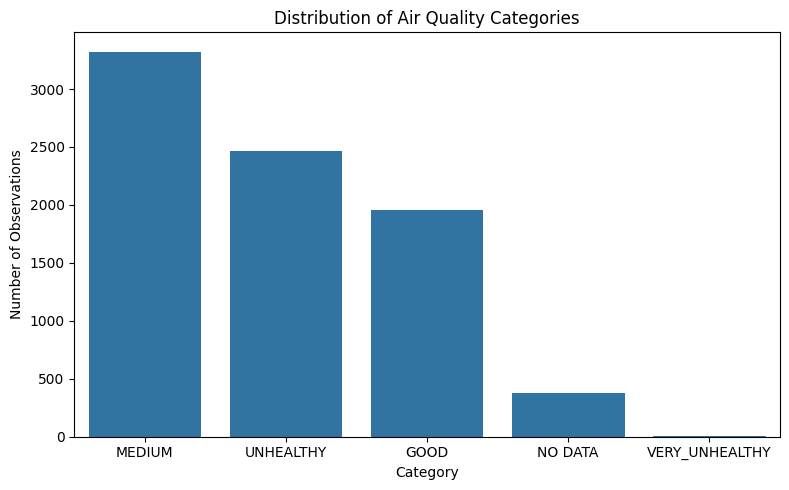

In [10]:
plt.figure(figsize = (8,5))
sns.barplot(
    data = category_counts,
    x = "category",
    y = "count"
)

plt.title("Distribution of Air Quality Categories")
plt.xlabel("Category")
plt.ylabel("Number of Observations")
plt.tight_layout()
plt.savefig(
    '../outputs/distribusi.png',
    dpi = 300,
    bbox_inches = 'tight'
)
plt.show()

<h4>3.2 Distribusi Observasi Ground Per Station</h4>

<h5>3.2.1 Jumlah Data Per Station</h5>

In [15]:
locals().keys()

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__session__', '_i', '_ii', '_iii', '_i1', 'os', 'pd', 'np', 'plt', 'sns', '_i2', 'PROCESSED_DIR', 'MERGED_PATH', 'df', '_2', '_i3', '_3', '_i4', 'summary', '_4', '_i5', 'station_counts', '_5', '_i6', 'year_counts', '_6', '_i7', 'label_cols', 'ground_feature_cols', 's5p_cols', 'modis_cols', 'viirs_cols', 'feature_groups', 'k', 'v', '_i8', '_8', '_i9', 'category_counts', '_9', '_i10', '_i11', '_i12', '_i13', '_i14', '_i15'])

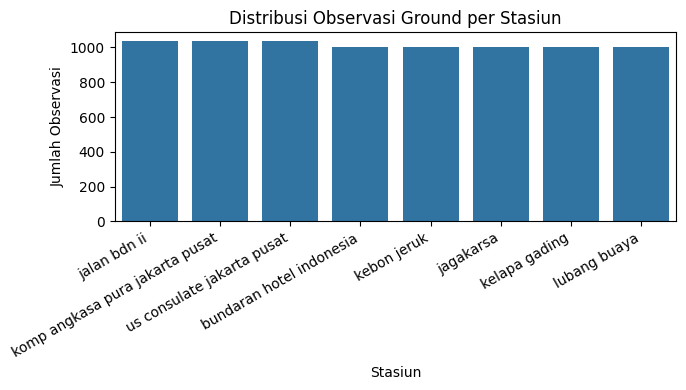

In [16]:
plt.figure(figsize=(7,4))
sns.barplot(
    data=station_counts,
    x="station",
    y="n_records"
)
plt.title("Distribusi Observasi Ground per Stasiun")
plt.xlabel("Stasiun")
plt.ylabel("Jumlah Observasi")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


<h5>3.2.2 Distribusi Kategori Per Tahun</h5>

In [17]:
category_year = (
    df.groupby(["year", "category"])
      .size()
      .rename("count")
      .reset_index()
)

category_year

,year,category,count
0,2023,GOOD,471
1,2023,MEDIUM,1700
2,2023,NO DATA,311
3,2023,UNHEALTHY,435
4,2023,VERY_UNHEALTHY,3
5,2024,GOOD,628
6,2024,MEDIUM,405
7,2024,NO DATA,58
8,2024,UNHEALTHY,1837
9,2025,GOOD,859


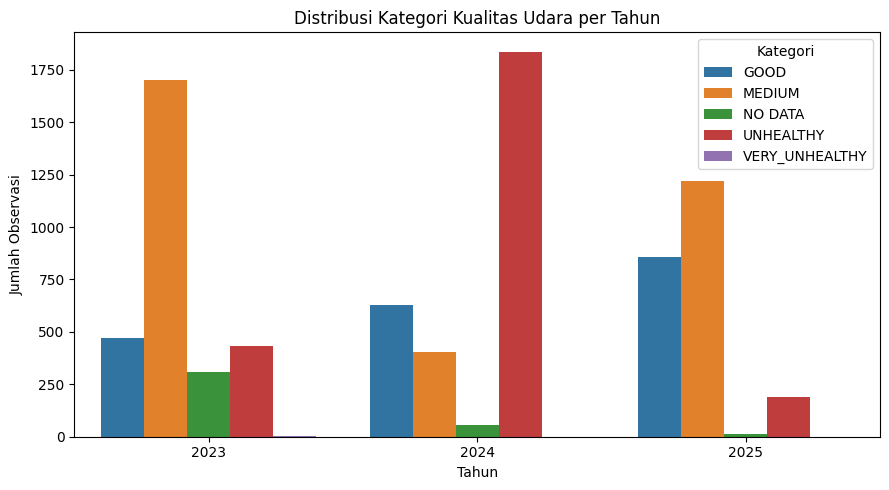

In [18]:
plt.figure(figsize=(9,5))
sns.barplot(
    data=category_year,
    x="year",
    y="count",
    hue="category"
)
plt.title("Distribusi Kategori Kualitas Udara per Tahun")
plt.xlabel("Tahun")
plt.ylabel("Jumlah Observasi")
plt.legend(title="Kategori")
plt.tight_layout()
plt.show()


<h2>4. EDA Data Satelit (Input)</h2>

<h4>4.1 Identifikasi Satelit</h4>

In [19]:
s5p_cols = [c for c in df.columns if c.startswith("s5p_")]
modis_cols = ["modis_MODIS_AOD_047"] #[c for c in df.columns if c.startswith("modis_")]
viirs_cols = ["viirs_VIIRS_NTL"] #[c for c in df.columns if c.startswith("viirs_")]

print("Sentinel-5P Features : ", s5p_cols)
print("MODIS Features : ", modis_cols)
print("VIIRS Features : ", viirs_cols)

Sentinel-5P Features :  ['s5p_co', 's5p_no2', 's5p_o3', 's5p_so2']
MODIS Features :  ['modis_MODIS_AOD_047']
VIIRS Features :  ['viirs_VIIRS_NTL']


<h4>4.2 Distribusi Nilai Satelit</h4>

<h5>4.2.1. Distribusi S5P</h5>

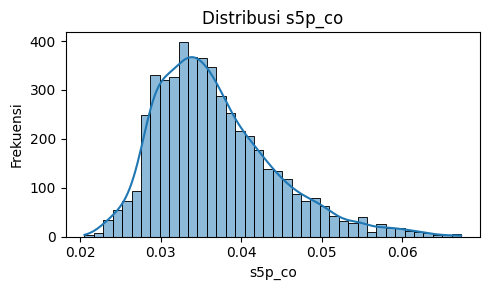

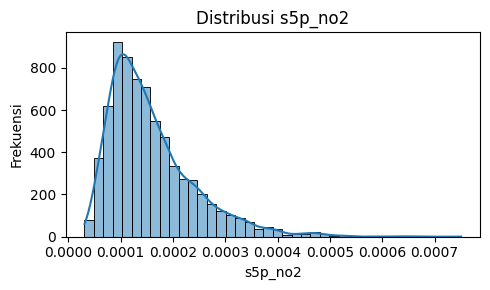

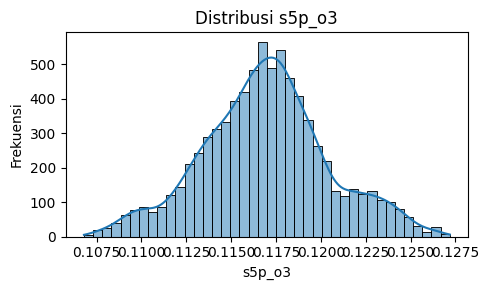

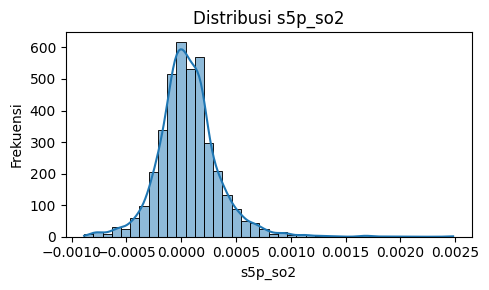

In [20]:
for col in s5p_cols :
    plt.figure(figsize = (5,3))
    sns.histplot(df[col], bins = 40, kde = True)
    plt.title(f"Distribusi {col}")
    plt.xlabel(col)
    plt.ylabel("Frekuensi")
    plt.tight_layout()
    plt.show()

<h5>4.2.2 Distribusi MODIS</h5>

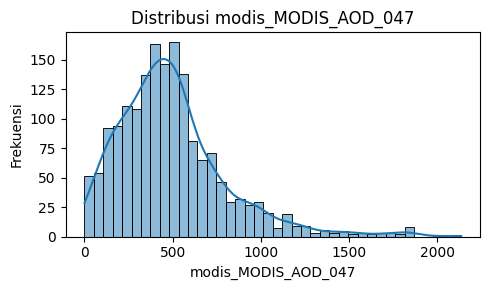

In [21]:
for col in modis_cols:
    plt.figure(figsize=(5,3))
    sns.histplot(df[col], bins=40, kde=True)
    plt.title(f"Distribusi {col}")
    plt.xlabel(col)
    plt.ylabel("Frekuensi")
    plt.tight_layout()
    plt.show()

<h5>4.2.3 Distribusi VIIRS</h5>

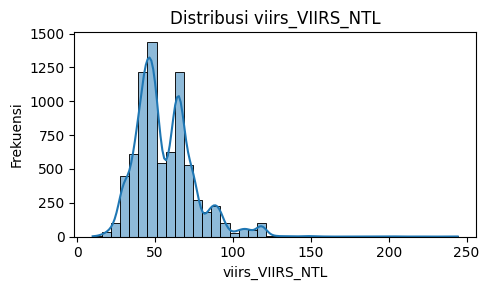

In [22]:
for col in viirs_cols:
    plt.figure(figsize=(5,3))
    sns.histplot(df[col], bins=40, kde=True)
    plt.title(f"Distribusi {col}")
    plt.xlabel(col)
    plt.ylabel("Frekuensi")
    plt.tight_layout()
    plt.show()


<h4>4.3 Missing Value Analsis</h4>

<h5>4.3.1 Persentase Missing per Fitur</h5>

In [23]:
satellite_cols = s5p_cols + modis_cols + viirs_cols

missing_sat = (
    df[satellite_cols]
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index()
)

missing_sat.columns = ["feature", "missing_percentage"]
missing_sat


,feature,missing_percentage
0,modis_MODIS_AOD_047,78.523077
1,s5p_so2,51.692308
2,s5p_co,37.735385
3,s5p_no2,12.012308
4,s5p_o3,4.356923
5,viirs_VIIRS_NTL,4.024615


<h5>4.3.2 Ringkasan Missing Per Sumber</h5>

In [24]:
missing_summary = {
    "Sentinel-5P": df[s5p_cols].isna().mean().mean() * 100 if s5p_cols else np.nan,
    "MODIS": df[modis_cols].isna().mean().mean() * 100 if modis_cols else np.nan,
    "VIIRS": df[viirs_cols].isna().mean().mean() * 100 if viirs_cols else np.nan
}

pd.DataFrame(missing_summary, index=["avg_missing_%"]).T


,avg_missing_%
Sentinel-5P,26.449231
MODIS,78.523077
VIIRS,4.024615


<h4>4.4 Pola Missing (Waktu & Stasiun)</h4>

In [25]:
if s5p_cols:
    missing_s5p_station = (
        df.groupby("station")[s5p_cols]
          .apply(lambda x: x.isna().mean().mean() * 100)
          .reset_index(name="missing_%")
    )

    missing_s5p_station


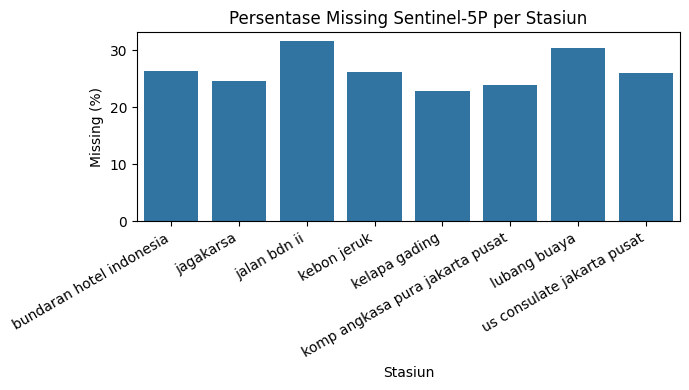

In [26]:
plt.figure(figsize=(7,4))
sns.barplot(
    data=missing_s5p_station,
    x="station",
    y="missing_%"
)
plt.title("Persentase Missing Sentinel-5P per Stasiun")
plt.xlabel("Stasiun")
plt.ylabel("Missing (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


In [27]:
if modis_cols:
    missing_modis_station = (
        df.groupby("station")[modis_cols]
          .apply(lambda x: x.isna().mean().mean() * 100)
          .reset_index(name="missing_%")
    )

    missing_modis_station


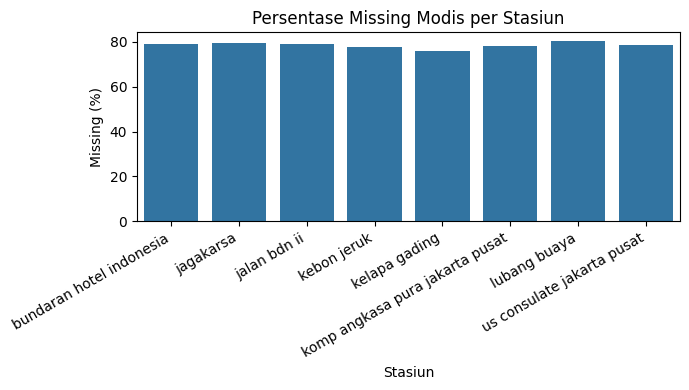

In [28]:
plt.figure(figsize=(7,4))
sns.barplot(
    data=missing_modis_station,
    x="station",
    y="missing_%"
)
plt.title("Persentase Missing Modis per Stasiun")
plt.xlabel("Stasiun")
plt.ylabel("Missing (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


In [29]:
if viirs_cols:
    missing_viirs_station = (
        df.groupby("station")[viirs_cols]
          .apply(lambda x: x.isna().mean().mean() * 100)
          .reset_index(name="missing_%")
    )

    missing_viirs_station


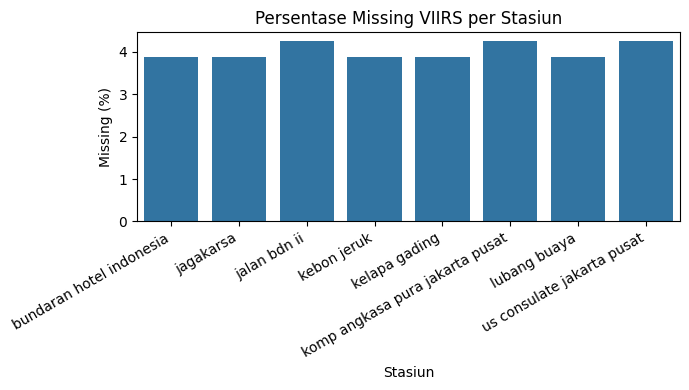

In [30]:
plt.figure(figsize=(7,4))
sns.barplot(
    data=missing_viirs_station,
    x="station",
    y="missing_%"
)
plt.title("Persentase Missing VIIRS per Stasiun")
plt.xlabel("Stasiun")
plt.ylabel("Missing (%)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


<h4>4.5 Gabungan Figure</h4>

In [31]:
sentinel_cols = ['s5p_co', 's5p_no2', 's5p_o3', 's5p_so2']
modis_cols    = ['modis_MODIS_AOD_047']
viirs_cols    = ['viirs_VIIRS_NTL']

def missing_percentage(df, columns, satellite_name):
    return (
        df[columns]
        .isna()
        .mean()
        .mul(100)
        .reset_index()
        .rename(columns={'index': 'variable', 0: 'missing_pct'})
        .assign(satellite=satellite_name)
    )

missing_s5p   = missing_percentage(df, sentinel_cols, 'Sentinel-5P')
missing_modis = missing_percentage(df, modis_cols, 'modis_MODIS_AOD_047')
missing_viirs = missing_percentage(df, viirs_cols, 'VIIRS')

missing_all = pd.concat(
    [missing_s5p, missing_modis, missing_viirs],
    ignore_index=True
)


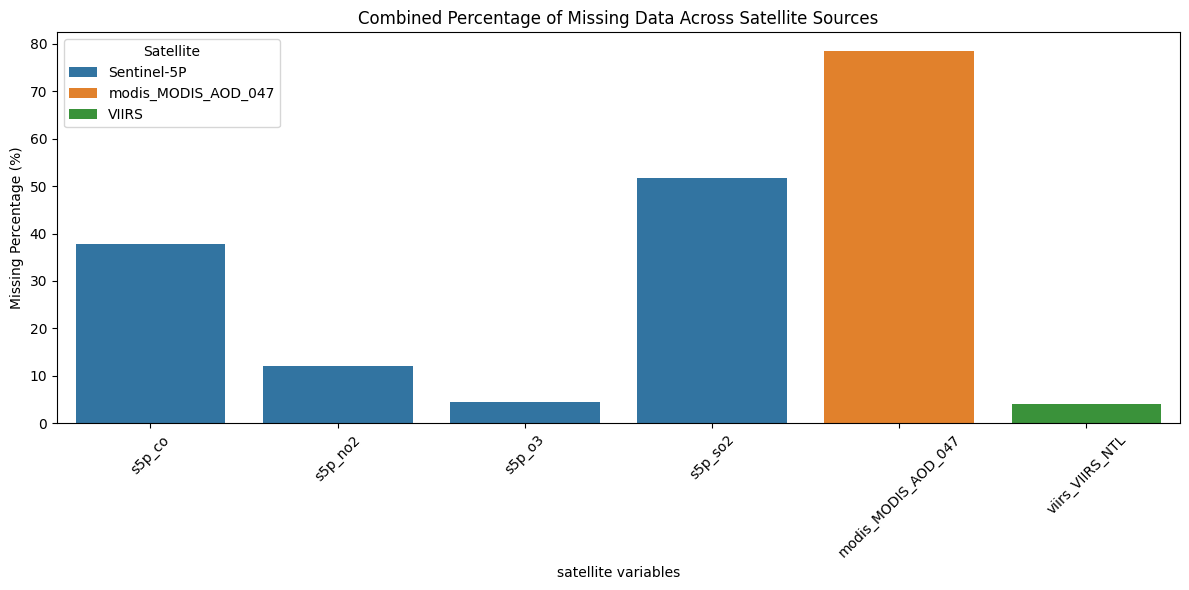

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(
    data=missing_all,
    x='variable',
    y='missing_pct',
    hue='satellite'
)

plt.ylabel('Missing Percentage (%)')
plt.xlabel('satellite variables')
plt.title('Combined Percentage of Missing Data Across Satellite Sources')
plt.xticks(rotation=45)
plt.legend(title='Satellite')
plt.tight_layout()

plt.savefig(
    '../outputs/eda_missing.png',
    dpi = 300,
    bbox_inches = 'tight'
)

plt.show()


<h2>5. Relasi Fitur Satelit - Kategori Ground</h2>

<h4>5.1 Sentinel-5P - Kategori</h4>

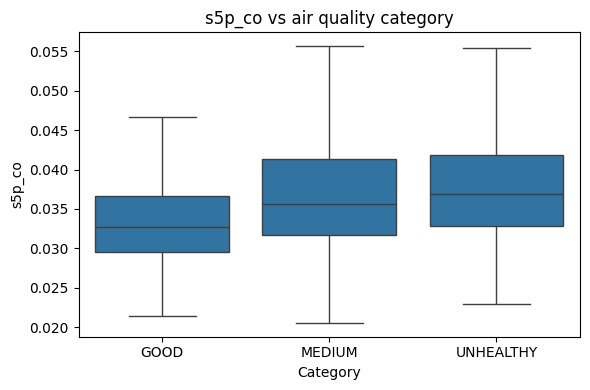

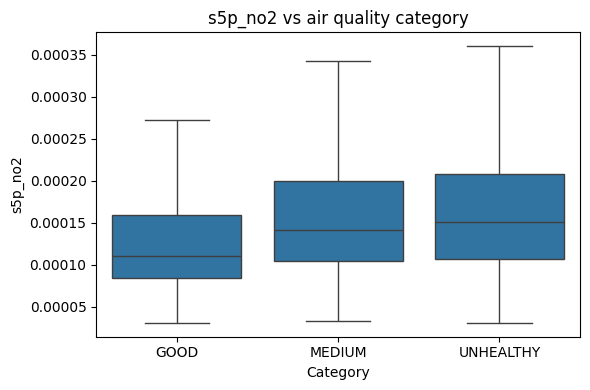

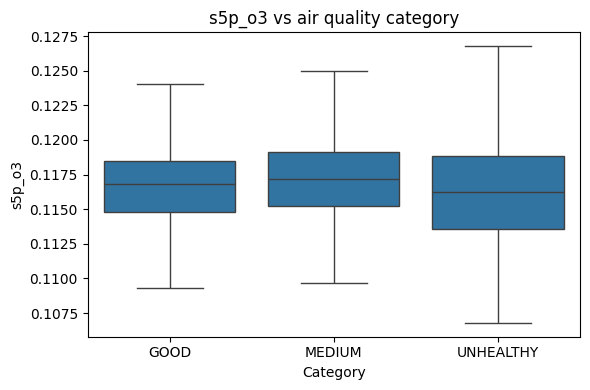

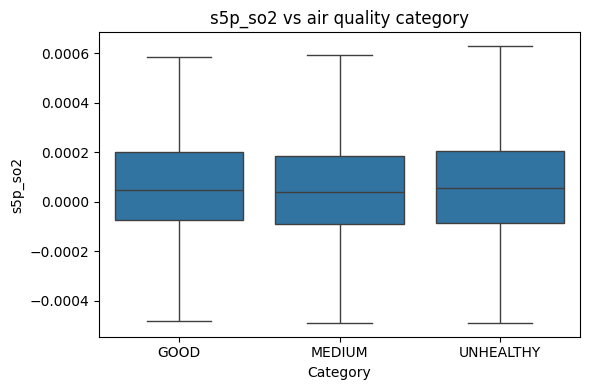

In [33]:
category_order = ["GOOD", "MEDIUM", "UNHEALTHY"]

for col in s5p_cols :
    plt.figure(figsize = (6,4))
    sns.boxplot(
        data = df,
        x = "category",
        y = col,
        order = category_order,
        showfliers = False
    )

    plt.title(f"{col} vs air quality category")
    plt.xlabel("Category")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

<h4>5.2 MODIS - Kategori</h4>

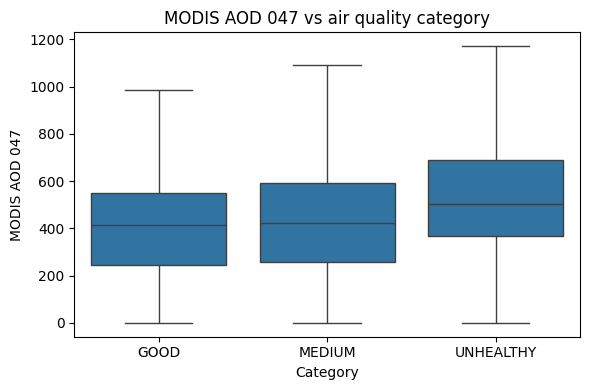

In [34]:
display_name = "MODIS AOD 047"

for col in modis_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(
        data=df,
        x="category",
        y=col,
        order=category_order,
        showfliers=False
    )
    
    plt.title(f"{display_name} vs air quality category")
    plt.xlabel("Category")
    plt.ylabel(display_name)
    plt.tight_layout()
    plt.savefig(
        '../outputs/boxplot_modis.png',
        dpi = 300,
        bbox_inches = 'tight'
    )
    plt.show()


<h4>5.3 VIIRS - Kategori</h4>

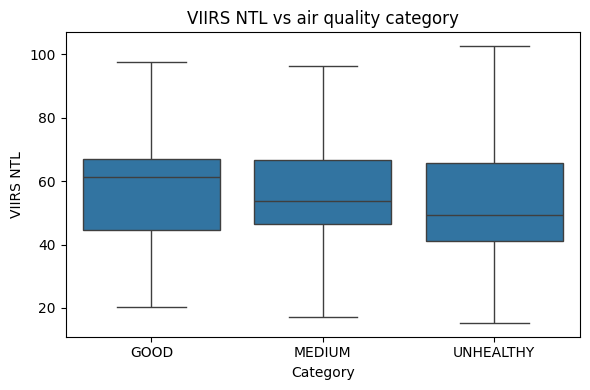

In [35]:
display_viirs = "VIIRS NTL"

for col in viirs_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(
        data=df,
        x="category",
        y=col,
        order=category_order,
        showfliers=False
    )
    plt.title(f"{display_viirs} vs air quality category")
    plt.xlabel("Category")
    plt.ylabel(display_viirs)
    plt.tight_layout()
    plt.show()
